## Add BioVariables to the **Final Dataset** and convert to **Annual** ##

In [1]:
import pandas as pd
import geopandas as gpd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys
import rpy2.robjects as robjects
import rpy2.ipython.html
from rpy2.robjects.packages import importr

rpy2.ipython.html.init_printing()

sys.path.insert(0, "../../../../Modules")

from utils import *


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 20
#pd.options.display.float_format = lambda x: '%.6f' % x

c:\Users\dimit\Python Virtual Environments\noa_eywa\Lib\site-packages\rpy2\robjects\packages.py:367: UserWarning: The symbol 'quartz' is not in this R namespace/package.
  warnings.warn(


In [2]:
NUTS0 = 'GR'
NUTS2 = 'CMacedonia'
NUTS2_ID = 'EL52'

In [3]:
dataset_monthly = pd.read_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_NUTS3_2009_2023.csv", encoding = enc)
dataset_monthly

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,2009-01,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.217953,40.552111,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.024023,-2.005545,1.509239,5.166060,NaN,NaN,NaN,0.057874,NaN,NaN,NaN,2.696421,NaN,NaN,NaN,7.182207,47.966593,149.890159,213.071312,222.648418,617.518519,19.919952,12539.943412,1443.131992,9.388889,150.420434,446.568965,173.562388,0.001137,31.186502,430.952681,91.643222,0,53.475540,2.926239,142.953571,0.0,1.0,22226.661302,3839.763398,39,295.276868,1788.438240,211.050676,0.061404,1081.096069,6174.903447,981.763520,9.317091,56.534301,531.903903,13.186846,0.008356,148.249642,31,36,30,12,12,1,6,7,2,-11.190000,12.110000,222.648418,0,14.333333,19.666667,40.972222,832.120329,37.0,-11.0,48.0,5.500000,23.500000,24.000000,4.166667,1455.0,296.0,45.0,62.908014,664.0,194.0,259.0,576.0,11723.0,44888.0,13557.0,70168.0,11361.0,44491.0,16024.0,71876.0,2098.63,NaN,NaN
1,2009-01,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,23.139033,40.693632,1,2009,0.168991,0.328042,0.189503,-0.328042,0.151776,0.329784,0.194638,-0.329784,0.044706,0.092952,0.120742,0.092952,7.062771,-0.527071,3.315124,7.145869,NaN,NaN,NaN,-0.061709,NaN,NaN,NaN,3.542080,NaN,NaN,NaN,7.153071,45.480772,149.749540,219.994285,221.745214,337.828125,10.897681,8593.386973,1597.882225,7.328125,157.212688,262.720171,181.411239,0.100946,37.829694,0.000000,27.527920,0,0.000000,-0.110060,166.990069,0.0,1.0,23002.186702,4365.002425,29,275.024254,879.827019,205.433801,2.743756,854.107751,5648.180704,1134.007243,6.485732,53.055866,219.572636,6.167415,0.415266,122.459953,31,30,30,10,10,1,6,6,2,-5.581294,12.866563,221.745214,0,16.083333,21.166667,45.035461,888.265248,42.0,-5.0,47.0,7.166667,9.500000,27.333333,5.666667,1324.0,291.0,35.0,66.632744,587.0,184.0,280.0,547.0,87281.0,374669.0,80103.0,542053.0,83839.0,403005.0,104992.0,591836.0,21520.33,NaN,NaN
2,2009-01,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.762317,41.016275,1,2009,0.218688,0.054729,-0.151006,-0.054729,0.213303,0.057652,-0.139077,-0.057652,0.041294,0.052580,0.070135,0.052580,7.286387,-2.417355,2.488471,7.289129,NaN,NaN,NaN,-1.712222,NaN,NaN,NaN,2.788454,NaN,NaN,NaN,7.194280,48.061819,151.273150,221.102476,223.022679,310.630435,10.020337,11937.024369,1406.325900,6.891304,173.111898,244.192094,180.215624,0.000489,14.857080,838.981974,55.964179,0,51.972498,21.046828,155.354599,0.0,1.0,22771.829003,3753.170334,32,324.927224,972.921816,192.844282,0.024394,600.402036,5165.145977,898.772903,6.847566,49.810356,194.999143,7.768504,0.003223,63.053429,31,36,30,12,12,3,5,8,2,-8.991429,

<Axes: >

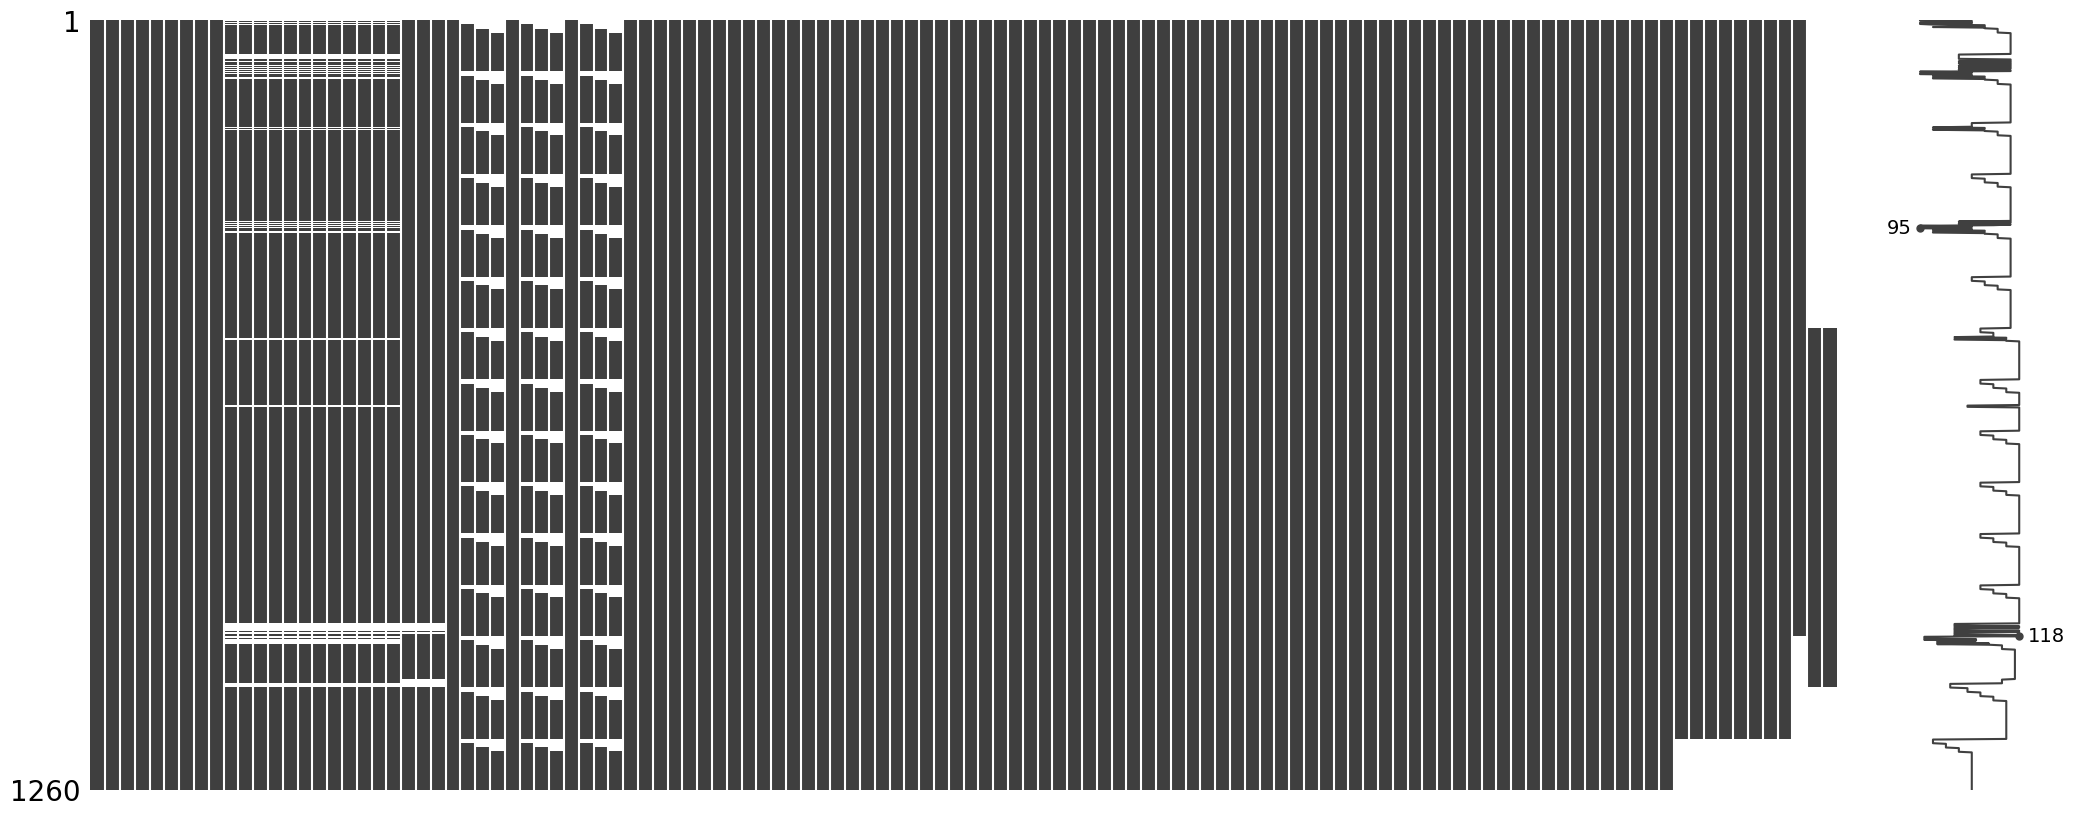

In [4]:
missingno.matrix(dataset_monthly)

In [5]:
missing = describe_dataframe(dataset_monthly, remove_zeros=True)
missing

,Column,Missing
9,ndvi,6.0317
10,ndmi,6.0317
11,ndwi,6.0317
12,ndbi,6.0317
13,ndvi_mean,5.9524
...,...,...
113,F_Y_GE65,6.6667
114,F_TOTAL,6.6667
115,MIO_EUR,20.0000
116,L_TOTAL,53.3333


In [6]:
years = dataset_monthly.year.unique()
nuts3_units = dataset_monthly.NUTS3_ID.unique()

In [7]:
data_p1 = []
data_p2 = []

for year in years[1:]:
    for region in nuts3_units:
        df_regional = dataset_monthly.loc[(dataset_monthly['NUTS3_ID'] == region)].copy()
        df_regional.reset_index(drop = True, inplace = True)

        df_period_1 = df_regional.loc[((df_regional['year'] == year-1) & (df_regional['month'] >= 11)) | ((df_regional['year'] == year) & (df_regional['month'] == 1))].copy()
        df_period_2 = df_regional.loc[((df_regional['year'] == year-1) & (df_regional['month'] >= 11)) | ((df_regional['year'] == year) & (df_regional['month'] <= 4))].copy()
        #df_period_2 = df_regional.loc[(df_regional['year'] == 2011) & (df_regional['month'] >= 2) & (df_regional['month'] <= 4)].copy()
        df_prev_year = df_regional.loc[(df_regional['year'] == year-1)].copy()
        df_curr_year = df_regional.loc[(df_regional['year'] == year)].copy()

        x = df_curr_year['x'].mean()
        y = df_curr_year['y'].mean()

        ndvi_p1 = df_period_1['ndvi'].mean()
        ndwi_p1 = df_period_1['ndwi'].mean()
        ndmi_p1 = df_period_1['ndmi'].mean()
        ndbi_p1 = df_period_1['ndbi'].mean()

        ndvi_p2 = df_period_2['ndvi'].mean()
        ndwi_p2 = df_period_2['ndwi'].mean()
        ndmi_p2 = df_period_2['ndmi'].mean()
        ndbi_p2 = df_period_2['ndbi'].mean()
        #------------------------------------------------------
        lst_mean_p1 = df_period_1['lst_mean'].mean()
        lst_day_mean_p1 = df_period_1['lst_day_mean'].mean()
        lst_night_mean_p1 = df_period_1['lst_night_mean'].mean()
        lst_min_p1 = df_period_1['monthly_lst_min'].min()
        lst_max_p1 = df_period_1['monthly_lst_min'].max()

        lst_mean_p2 = df_period_2['lst_mean'].mean()
        lst_day_mean_p2 = df_period_2['lst_day_mean'].mean()
        lst_night_mean_p2 = df_period_2['lst_night_mean'].mean()
        lst_min_p2 = df_period_2['monthly_lst_min'].min()
        lst_max_p2 = df_period_2['monthly_lst_min'].max()
        #-------------------------------------------------------
        prec_mean_p1 = df_period_1['rainfall_mean'].mean()
        prec_acc_p1 = df_period_1['monthly_acc_prec'].sum()

        prec_mean_p2 = df_period_2['rainfall_mean'].mean()
        prec_acc_p2 = df_period_2['monthly_acc_prec'].sum()
        #-------------------------------------------------------
        mosq_mean_p1 = df_period_1['mosq_pred_mean'].mean()
        mosq_sum_p1 = df_period_1['mosq_pred_acc'].sum()

        mosq_mean_p2 = df_period_2['mosq_pred_mean'].mean()
        mosq_sum_p2 = df_period_2['mosq_pred_acc'].sum()
        #--------------------------------------------------------
        bio1 = df_prev_year.iloc[0]['bio1']
        bio2 = df_prev_year.iloc[0]['bio2']
        bio3 = df_prev_year.iloc[0]['bio3']
        bio4 = df_prev_year.iloc[0]['bio4']
        bio5 = df_prev_year.iloc[0]['bio5']
        bio6 = df_prev_year.iloc[0]['bio6']
        bio7 = df_prev_year.iloc[0]['bio7']
        bio8 = df_prev_year.iloc[0]['bio8']
        bio9 = df_prev_year.iloc[0]['bio9']
        bio10 = df_prev_year.iloc[0]['bio10']
        bio11 = df_prev_year.iloc[0]['bio11']
        bio12 = df_prev_year.iloc[0]['bio12']
        bio13 = df_prev_year.iloc[0]['bio13']
        bio14 = df_prev_year.iloc[0]['bio14']
        bio15 = df_prev_year.iloc[0]['bio15']
        bio16 = df_prev_year.iloc[0]['bio16']
        bio17 = df_prev_year.iloc[0]['bio17']
        bio18 = df_prev_year.iloc[0]['bio18']
        bio19 = df_prev_year.iloc[0]['bio19']
        #--------------------------------------------------------
        lc_prop1 = df_prev_year.iloc[0]['lc_prop1']
        lc_prop2 = df_prev_year.iloc[0]['lc_prop2']
        lc_prop3 = df_prev_year.iloc[0]['lc_prop3']
        lc_type1 = df_prev_year.iloc[0]['lc_type1']
        lc_type2 = df_prev_year.iloc[0]['lc_type2']
        lc_type3 = df_prev_year.iloc[0]['lc_type3']
        lc_type4 = df_prev_year.iloc[0]['lc_type4']
        lc_type5 = df_prev_year.iloc[0]['lc_type5']
        #--------------------------------------------------------
        distance_to_coast = df_prev_year.iloc[0]['distance_to_coast']
        distance_to_river = df_prev_year.iloc[0]['distance_to_river']
        slope_mean_1km = df_prev_year.iloc[0]['slope_mean_1km']
        aspect_mean_200m = df_prev_year.iloc[0]['aspect_mean_200m']
        elevation_mean_1km = df_prev_year.iloc[0]['elevation_mean_1km']
        hillshade_mean_1km = df_prev_year.iloc[0]['hillshade_mean_1km']
        fs_area_1km = df_prev_year.iloc[0]['fs_area_1km']
        flow_accu_200m = df_prev_year.iloc[0]['flow_accu_200m']

        distance_to_coast_std = df_prev_year.iloc[0]['distance_to_coast_std']
        distance_to_river_std = df_prev_year.iloc[0]['distance_to_river_std']
        slope_mean_1km_std = df_prev_year.iloc[0]['slope_mean_1km_std']
        aspect_mean_200m_std = df_prev_year.iloc[0]['aspect_mean_200m_std']
        elevation_mean_1km_std = df_prev_year.iloc[0]['elevation_mean_1km_std']
        hillshade_mean_1km_std = df_prev_year.iloc[0]['hillshade_mean_1km_std']
        fs_area_1km_std = df_prev_year.iloc[0]['fs_area_1km_std']
        flow_accu_200m_std = df_prev_year.iloc[0]['flow_accu_200m_std']
        #--------------------------------------------------------
        males_lt15 = df_prev_year.iloc[0]['M_Y_LT15']
        males_15t64 = df_prev_year.iloc[0]['M_Y15-64']
        males_gt65 = df_prev_year.iloc[0]['M_Y_GE65']
        males_total = df_prev_year.iloc[0]['M_TOTAL']

        females_lt15 = df_prev_year.iloc[0]['F_Y_LT15']
        females_15t64 = df_prev_year.iloc[0]['F_Y15-64']
        females_gt65 = df_prev_year.iloc[0]['F_Y_GE65']
        females_total = df_prev_year.iloc[0]['F_TOTAL']

        mio_eur = df_prev_year.iloc[0]['MIO_EUR']
        l_total = df_prev_year.iloc[0]['L_TOTAL']
        unl_total = df_prev_year.iloc[0]['UNL_TOTAL']
        #--------------------------------------------------------
        cases_total = df_curr_year['cases'].sum()
        cases_arr = df_curr_year.loc[(df_curr_year['month'] >= 5) & (df_curr_year['month'] <= 10)]['cases'].to_list()

        data_p1.append({'NUTS3_ID': region, 
                     'year': year, 
                     'x' : x,
                     'y': y,
                     'ndvi_p1': ndvi_p1,
                     'ndwi_p1': ndwi_p1,
                     'ndmi_p1': ndmi_p1,
                     'ndbi_p1': ndbi_p1,
                     'lst_mean_p1': lst_mean_p1,
                     'lst_day_mean_p1': lst_day_mean_p1,
                     'lst_night_mean_p1': lst_night_mean_p1,
                     'lst_min_p1': lst_min_p1,
                     'lst_max_p1': lst_max_p1,
                     'prec_mean_p1': prec_mean_p1,
                     'prec_acc_p1': prec_acc_p1,
                     'mosq_mean_p1': mosq_mean_p1,
                     'mosq_sum_p1': mosq_sum_p1,
                     'bio1': bio1,
                     'bio2': bio2,
                     'bio3': bio3,
                     'bio4': bio4,
                     'bio5': bio5,
                     'bio6': bio6,
                     'bio7': bio7,
                     'bio8': bio8,
                     'bio9': bio9,
                     'bio10': bio10,
                     'bio11': bio11,
                     'bio12': bio12,
                     'bio13': bio13,
                     'bio14': bio14,
                     'bio15': bio15,
                     'bio16': bio16,
                     'bio17': bio17,
                     'bio18': bio18,
                     'bio19': bio19,
                     'lc_prop1': lc_prop1,
                     'lc_prop2': lc_prop2,
                     'lc_prop3': lc_prop3,
                     'lc_type1': lc_type1,
                     'lc_type2': lc_type2,
                     'lc_type3': lc_type3,
                     'lc_type4': lc_type4,
                     'lc_type5': lc_type5,
                     'distance_to_coast': distance_to_coast,
                     'distance_to_river': distance_to_river,
                     'slope_mean_1km': slope_mean_1km,
                     'aspect_mean_200m': aspect_mean_200m,
                     'elevation_mean_1km': elevation_mean_1km,
                     'hillshade_mean_1km': hillshade_mean_1km,
                     'fs_area_1km': fs_area_1km,
                     'flow_accu_200m': flow_accu_200m,
                     'distance_to_coast_std': distance_to_coast_std,
                     'distance_to_river_std': distance_to_river_std,
                     'slope_mean_1km_std': slope_mean_1km_std,
                     'aspect_mean_200m_std': aspect_mean_200m_std,
                     'elevation_mean_1km_std': elevation_mean_1km_std,
                     'hillshade_mean_1km_std': hillshade_mean_1km_std,
                     'fs_area_1km_std': fs_area_1km_std,
                     'flow_accu_200m_std': flow_accu_200m_std,
                     'males_lt15': males_lt15,
                     'males_15t64': males_15t64,
                     'males_gt65': males_gt65,
                     'males_total': males_total,
                     'females_lt15': females_lt15,
                     'females_15t64': females_15t64,
                     'females_gt65': females_gt65,
                     'females_total': females_total,
                     'mio_eur': mio_eur,
                     'l_total': l_total,
                     'unl_total': unl_total,
                     'mio_eur': mio_eur,
                     'cases_total': cases_total,
                     'cases_arr': cases_arr,
                     })

        data_p2.append({'NUTS3_ID': region, 
                     'year': year,
                     'x' : x,
                     'y': y, 
                     'ndvi_p2': ndvi_p2,
                     'ndwi_p2': ndwi_p2,
                     'ndmi_p2': ndmi_p2,
                     'ndbi_p2': ndbi_p2,
                     'lst_mean_p2': lst_mean_p2,
                     'lst_day_mean_p2': lst_day_mean_p2,
                     'lst_night_mean_p2': lst_night_mean_p2,
                     'lst_min_p2': lst_min_p2,
                     'lst_max_p2': lst_max_p2,
                     'prec_mean_p2': prec_mean_p2,
                     'prec_acc_p2': prec_acc_p2,
                     'mosq_mean_p2': mosq_mean_p2,
                     'mosq_sum_p2': mosq_sum_p2,
                     'bio1': bio1,
                     'bio2': bio2,
                     'bio3': bio3,
                     'bio4': bio4,
                     'bio5': bio5,
                     'bio6': bio6,
                     'bio7': bio7,
                     'bio8': bio8,
                     'bio9': bio9,
                     'bio10': bio10,
                     'bio11': bio11,
                     'bio12': bio12,
                     'bio13': bio13,
                     'bio14': bio14,
                     'bio15': bio15,
                     'bio16': bio16,
                     'bio17': bio17,
                     'bio18': bio18,
                     'bio19': bio19,
                     'lc_prop1': lc_prop1,
                     'lc_prop2': lc_prop2,
                     'lc_prop3': lc_prop3,
                     'lc_type1': lc_type1,
                     'lc_type2': lc_type2,
                     'lc_type3': lc_type3,
                     'lc_type4': lc_type4,
                     'lc_type5': lc_type5,
                     'distance_to_coast': distance_to_coast,
                     'distance_to_river': distance_to_river,
                     'slope_mean_1km': slope_mean_1km,
                     'aspect_mean_200m': aspect_mean_200m,
                     'elevation_mean_1km': elevation_mean_1km,
                     'hillshade_mean_1km': hillshade_mean_1km,
                     'fs_area_1km': fs_area_1km,
                     'flow_accu_200m': flow_accu_200m,
                     'distance_to_coast_std': distance_to_coast_std,
                     'distance_to_river_std': distance_to_river_std,
                     'slope_mean_1km_std': slope_mean_1km_std,
                     'aspect_mean_200m_std': aspect_mean_200m_std,
                     'elevation_mean_1km_std': elevation_mean_1km_std,
                     'hillshade_mean_1km_std': hillshade_mean_1km_std,
                     'fs_area_1km_std': fs_area_1km_std,
                     'flow_accu_200m_std': flow_accu_200m_std,
                     'males_lt15': males_lt15,
                     'males_15t64': males_15t64,
                     'males_gt65': males_gt65,
                     'males_total': males_total,
                     'females_lt15': females_lt15,
                     'females_15t64': females_15t64,
                     'females_gt65': females_gt65,
                     'females_total': females_total,
                     'mio_eur': mio_eur,
                     'l_total': l_total,
                     'unl_total': unl_total,
                     'mio_eur': mio_eur,
                     'cases_total': cases_total,
                     'cases_arr': cases_arr,
                     })
        
p1_df = pd.DataFrame(data_p1)       
p2_df = pd.DataFrame(data_p2) 

In [8]:
p1_df

,NUTS3_ID,year,x,y,ndvi_p1,ndwi_p1,ndmi_p1,ndbi_p1,lst_mean_p1,lst_day_mean_p1,lst_night_mean_p1,lst_min_p1,lst_max_p1,prec_mean_p1,prec_acc_p1,mosq_mean_p1,mosq_sum_p1,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,cases_total,cases_arr
0,EL521,2010,22.217953,40.552111,NaN,NaN,NaN,NaN,6.832007,10.274829,3.389185,-0.323333,1.440741,5.691801,524.456884,12.316395,1144.314815,14.333333,19.666667,40.972222,832.120329,37.0,-11.0,48.0,5.500000,23.500000,24.000000,4.166667,1455.0,296.0,45.0,62.908014,664.0,194.0,259.0,576.0,31,36,30,12,12,1,6,7,12539.943412,1443.131992,9.388889,150.420434,446.568965,173.562388,0.001137,31.186502,6174.903447,981.763520,9.317091,56.534301,531.903903,13.186846,0.008356,148.249642,11723.0,44888.0,13557.0,70168.0,11361.0,44491.0,16024.0,71876.0,2098.63,NaN,NaN,49,"[0, 0, 6, 36, 7, 0]"
1,EL522,2010,23.139033,40.693632,0.246671,-0.155465,0.054331,-0.054331,7.666022,11.889764,3.442280,-2.889219,3.587031,4.429008,409.388384,11.673538,1084.539062,16.083333,21.166667,45.035461,888.265248,42.0,-5.0,47.0,7.166667,9.500000,27.333333,5.666667,1324.0,291.0,35.0,66.632744,587.0,184.0,280.0,547.0,31,30,30,10,10,1,6,6,8593.386973,1597.882225,7.328125,157.212688,262.720171,181.411239,0.100946,37.829694,5648.180704,1134.007243,6.485732,53.055866,219.572636,6.167415,0.415266,122.459953,87281.0,374669.0,80103.0,542053.0,83839.0,403005.0,104992.0,591836.0,21520.33,NaN,NaN,81,"[0, 0, 11, 50, 20, 0]"
2,EL523,2010,22.762317,41.016275,0.240682,-0.239834,-0.012466,0.012466,6.672266,11.074669,2.269862,-4.752826,1.986957,4.711003,434.944488,9.033014,839.043478,16.041667,22.916667,44.070513,929.187899,44.0,-8.0,52.0,6.666667,9.333333,27.666667,5.333333,1381.0,286.0,41.0,63.457161,604.0,204.0,300.0,550.0,31,36,30,12,12,3,5,8,11937.024369,1406.325900,6.891304,173.111898,244.192094,180.215624,0.000489,14.857080,5165.145977,898.772903,6.847566,49.810356,194.999143,7.768504,0.003223,63.053429,5916.0,24162.0,9803.0,39881.0,5598.0,23417.0,11860.0,40875.0,1169.86,NaN,NaN,23,"[0, 0, 6, 13, 4, 0]"
3,EL524,2010,22.109782,40.888821,0.242562,-0.053267,0.147196,-0.147196,6.576489,10.600797,2.552180,-3.833409,0.897500,5.741834,528.670447,10.937382,1016.011364,14.708333,19.916667,43.297101,849.186331,38.0,-8.0,46.0,6.000000,24.500000,25.166667,4.666667,1512.0,287.0,44.0,60.410595,683.0,204.0,288.0,579.0,31,36,30,12,9,4,4,4,17697.449346,1077.933680,9.795455,157.290051,440.466296,179.112327,0.012547,110.007042,7916.034127,904.647695,9.200399,55.702042,405.320837,13.742301,0.117698,396.275480,11214.0,44608.0,14535.0,70357.0,11089.0,43192.0,17464.0,71745.0,2022.78,NaN,NaN,57,"[0, 0, 3, 41, 13, 0]"
4,EL525,2010,22.442423,40.269959,NaN,NaN,NaN,NaN,8.062156,11.409259,4.715053,0.756667,4.043333,4.973131,459.127417,12.127033,1126.222222,15.500000,19.500000,43.333333,837.745893,40.0,-5.0,45.0,7.333333,25.166667,26.000000,5.666667,1275.0,275.0,51.0,66.546526,571.0,176.0,199.0,521.0,31,36,30,12,12,1,6,7,10529.200600,979.257510,11.822222,148.678278,321.171339,171.108861,0.000000,14.790525,4937.303138,711.096679,8.798990,45.834550,379.451389,12.356155,0.000000,31.835228,10377.0,39695.0,11841.0,61913.0,10120.0,40015.0,14312.0,64447.0,1815.79,NaN,NaN,13,"[0, 0, 1, 7, 5, 0]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,..

In [9]:
p2_df

,NUTS3_ID,year,x,y,ndvi_p2,ndwi_p2,ndmi_p2,ndbi_p2,lst_mean_p2,lst_day_mean_p2,lst_night_mean_p2,lst_min_p2,lst_max_p2,prec_mean_p2,prec_acc_p2,mosq_mean_p2,mosq_sum_p2,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,cases_total,cases_arr
0,EL521,2010,22.217953,40.552111,0.353989,-0.190765,0.140956,-0.140956,8.226205,12.679895,3.772516,-4.091667,4.901481,5.590988,1001.929838,15.765601,2860.092593,14.333333,19.666667,40.972222,832.120329,37.0,-11.0,48.0,5.500000,23.500000,24.000000,4.166667,1455.0,296.0,45.0,62.908014,664.0,194.0,259.0,576.0,31,36,30,12,12,1,6,7,12539.943412,1443.131992,9.388889,150.420434,446.568965,173.562388,0.001137,31.186502,6174.903447,981.763520,9.317091,56.534301,531.903903,13.186846,0.008356,148.249642,11723.0,44888.0,13557.0,70168.0,11361.0,44491.0,16024.0,71876.0,2098.63,NaN,NaN,49,"[0, 0, 6, 36, 7, 0]"
1,EL522,2010,23.139033,40.693632,0.286727,-0.094388,0.159146,-0.159146,9.062688,13.908152,4.217224,-4.194062,6.827969,4.633141,829.349932,13.710643,2491.554688,16.083333,21.166667,45.035461,888.265248,42.0,-5.0,47.0,7.166667,9.500000,27.333333,5.666667,1324.0,291.0,35.0,66.632744,587.0,184.0,280.0,547.0,31,30,30,10,10,1,6,6,8593.386973,1597.882225,7.328125,157.212688,262.720171,181.411239,0.100946,37.829694,5648.180704,1134.007243,6.485732,53.055866,219.572636,6.167415,0.415266,122.459953,87281.0,374669.0,80103.0,542053.0,83839.0,403005.0,104992.0,591836.0,21520.33,NaN,NaN,81,"[0, 0, 11, 50, 20, 0]"
2,EL523,2010,22.762317,41.016275,0.237641,-0.022679,0.197625,-0.197625,8.509787,13.544245,3.475329,-5.153696,6.112391,4.466064,802.915035,13.273372,2409.163043,16.041667,22.916667,44.070513,929.187899,44.0,-8.0,52.0,6.666667,9.333333,27.666667,5.333333,1381.0,286.0,41.0,63.457161,604.0,204.0,300.0,550.0,31,36,30,12,12,3,5,8,11937.024369,1406.325900,6.891304,173.111898,244.192094,180.215624,0.000489,14.857080,5165.145977,898.772903,6.847566,49.810356,194.999143,7.768504,0.003223,63.053429,5916.0,24162.0,9803.0,39881.0,5598.0,23417.0,11860.0,40875.0,1169.86,NaN,NaN,23,"[0, 0, 6, 13, 4, 0]"
3,EL524,2010,22.109782,40.888821,0.319691,-0.178787,0.116277,-0.116277,8.099761,12.907913,3.291608,-4.296905,5.501364,5.547225,995.774511,15.403738,2790.295455,14.708333,19.916667,43.297101,849.186331,38.0,-8.0,46.0,6.000000,24.500000,25.166667,4.666667,1512.0,287.0,44.0,60.410595,683.0,204.0,288.0,579.0,31,36,30,12,9,4,4,4,17697.449346,1077.933680,9.795455,157.290051,440.466296,179.112327,0.012547,110.007042,7916.034127,904.647695,9.200399,55.702042,405.320837,13.742301,0.117698,396.275480,11214.0,44608.0,14535.0,70357.0,11089.0,43192.0,17464.0,71745.0,2022.78,NaN,NaN,57,"[0, 0, 3, 41, 13, 0]"
4,EL525,2010,22.442423,40.269959,0.378999,-0.255164,0.109803,-0.109803,9.232783,13.514089,4.951478,-3.229556,6.584222,5.067479,908.264117,18.863691,3417.888889,15.500000,19.500000,43.333333,837.745893,40.0,-5.0,45.0,7.333333,25.166667,26.000000,5.666667,1275.0,275.0,51.0,66.546526,571.0,176.0,199.0,521.0,31,36,30,12,12,1,6,7,10529.200600,979.257510,11.822222,148.678278,321.171339,171.108861,0.000000,14.790525,4937.303138,711.096679,8.798990,45.834550,379.451389,12.356155,0.000000,31.835228,10377.0,39695.0,11841.0,61913.0,10120.0,40015.0,14312.0,64447.0,1815.79,NaN,NaN,13,"[0, 0, 1, 7, 5, 0]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,..

<Axes: >

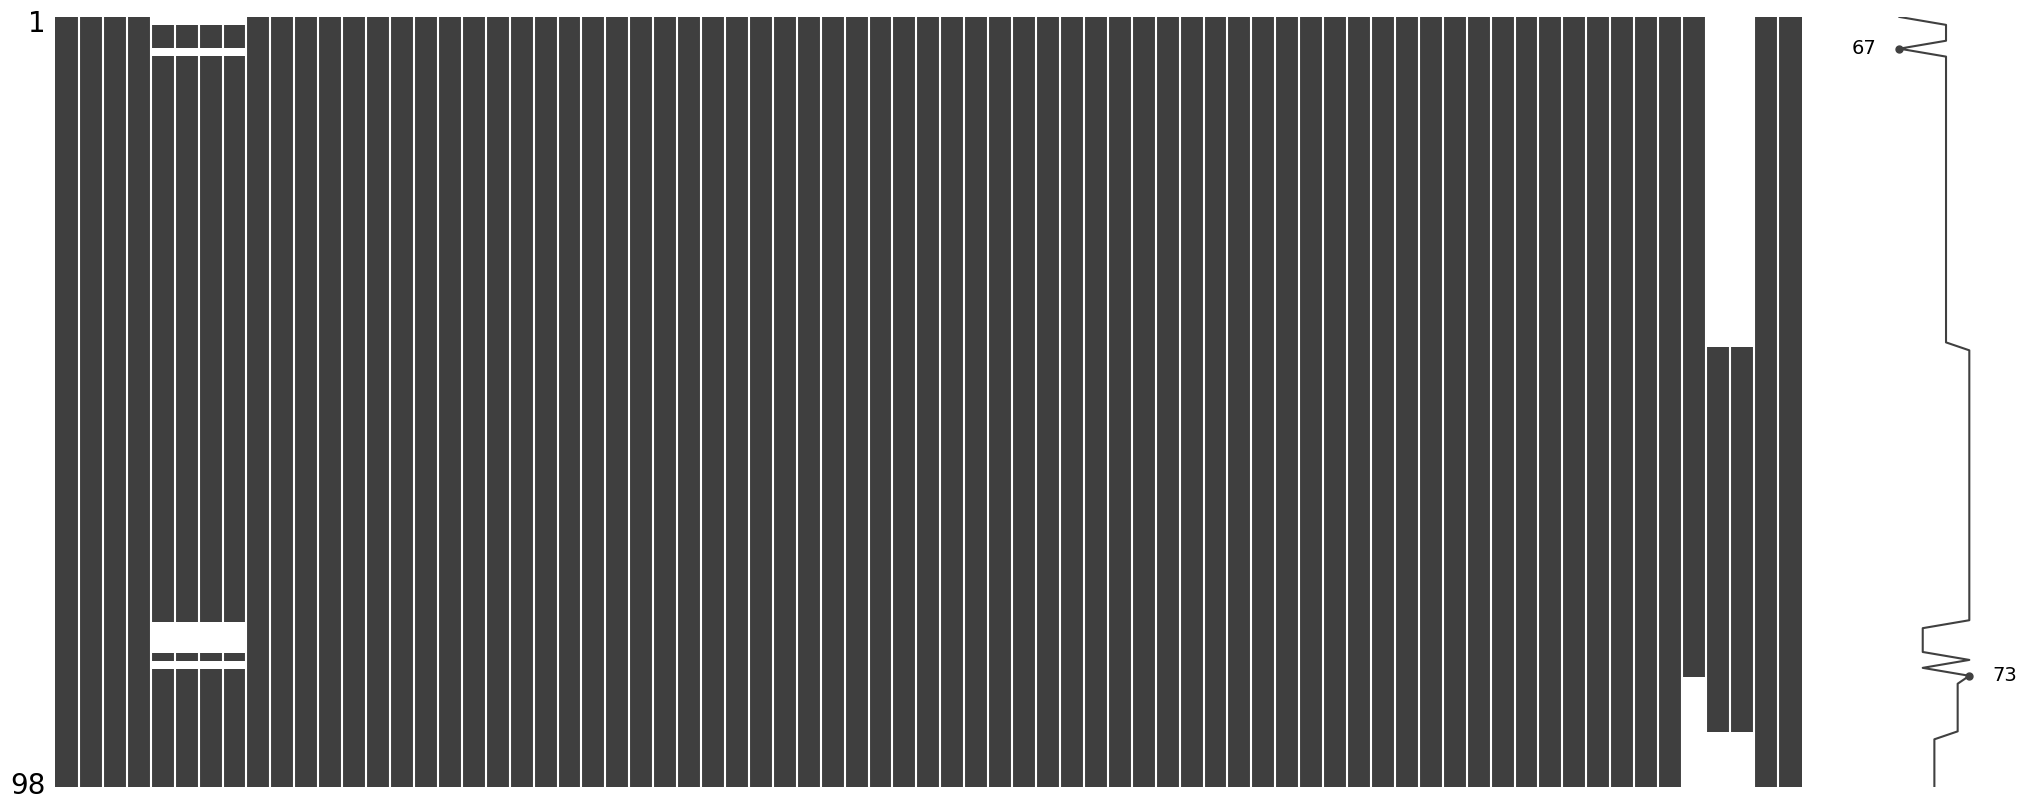

In [10]:
missingno.matrix(p1_df)

<Axes: >

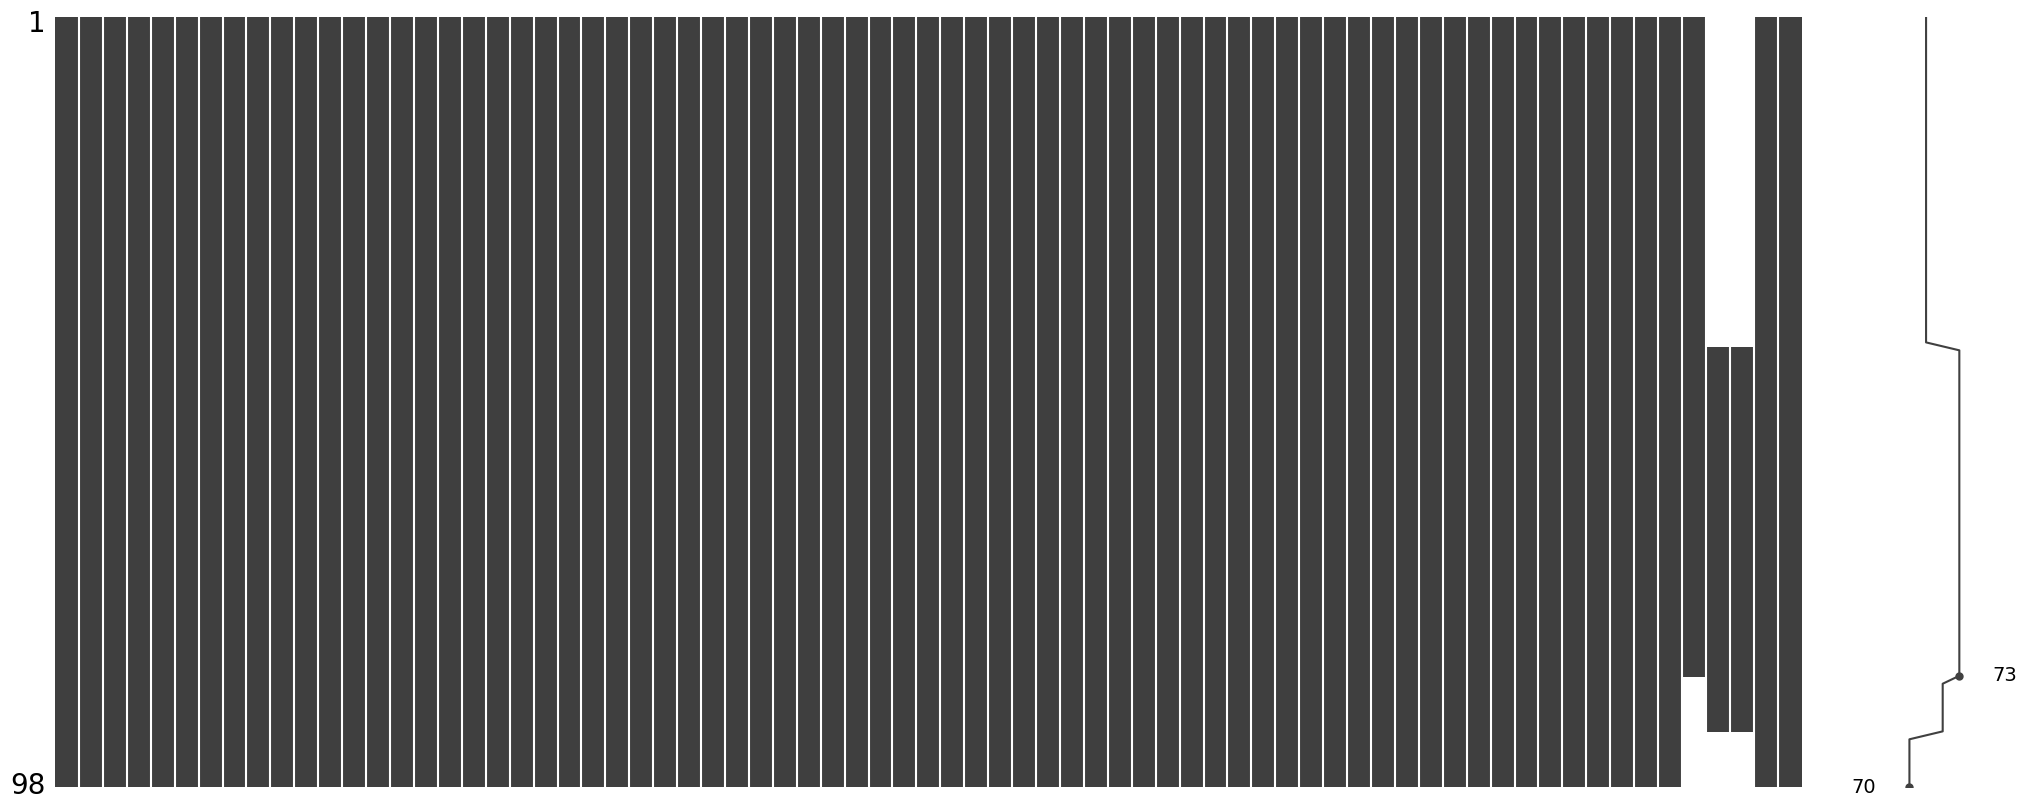

In [11]:
missingno.matrix(p2_df)

In [12]:
missing = describe_dataframe(p1_df, remove_zeros=True)
missing

,Column,Missing
4,ndvi_p1,7.1429
5,ndwi_p1,7.1429
6,ndmi_p1,7.1429
7,ndbi_p1,7.1429
68,mio_eur,14.2857
69,l_total,50.0000
70,unl_total,50.0000


In [13]:
missing = describe_dataframe(p2_df, remove_zeros=True)
missing

,Column,Missing
68,mio_eur,14.2857
69,l_total,50.0000
70,unl_total,50.0000


In [14]:
p1_df.cases_total.sum()

936

In [15]:
p2_df.cases_total.sum()

936

In [16]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'mio_eur']

temp_df = p1_df[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['mio_eur']

p1_df[imputed_columns] = imputed_data[imputed_columns]
p2_df[imputed_columns] = imputed_data[imputed_columns]

In [17]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'l_total']

temp_df = p1_df[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['l_total']

p1_df[imputed_columns] = imputed_data[imputed_columns]
p2_df[imputed_columns] = imputed_data[imputed_columns]

In [18]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'unl_total']

temp_df = p1_df[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['unl_total']

p1_df[imputed_columns] = imputed_data[imputed_columns]
p2_df[imputed_columns] = imputed_data[imputed_columns]

<Axes: >

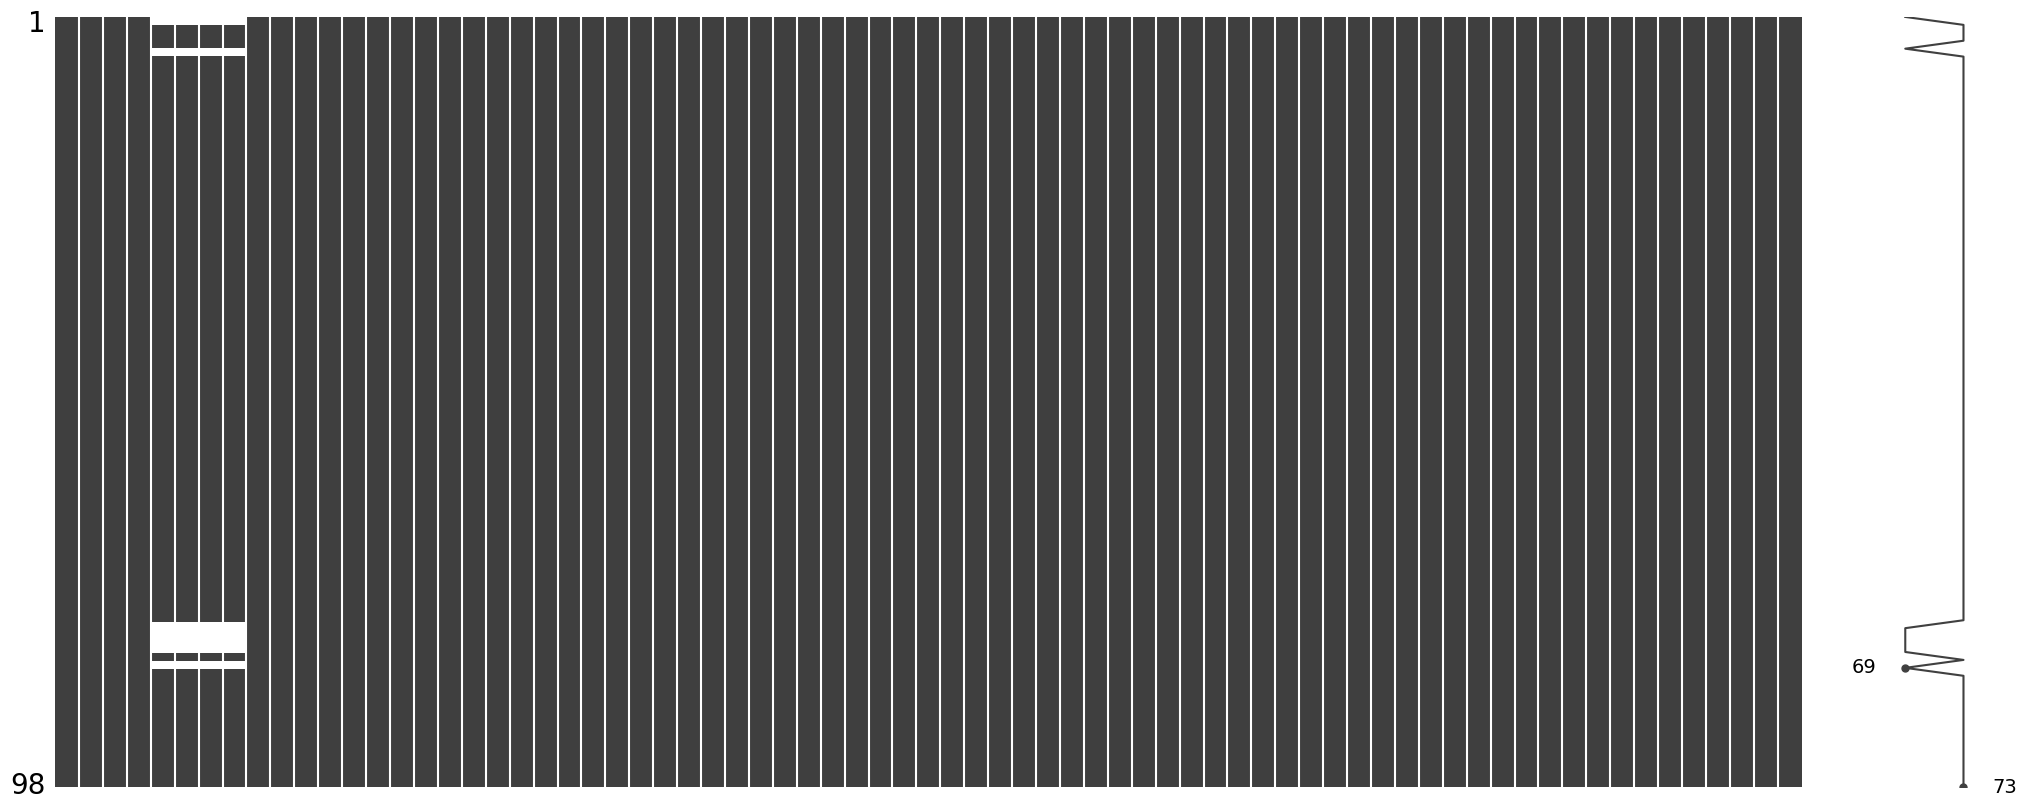

In [19]:
missingno.matrix(p1_df, label_rotation=90)

<Axes: >

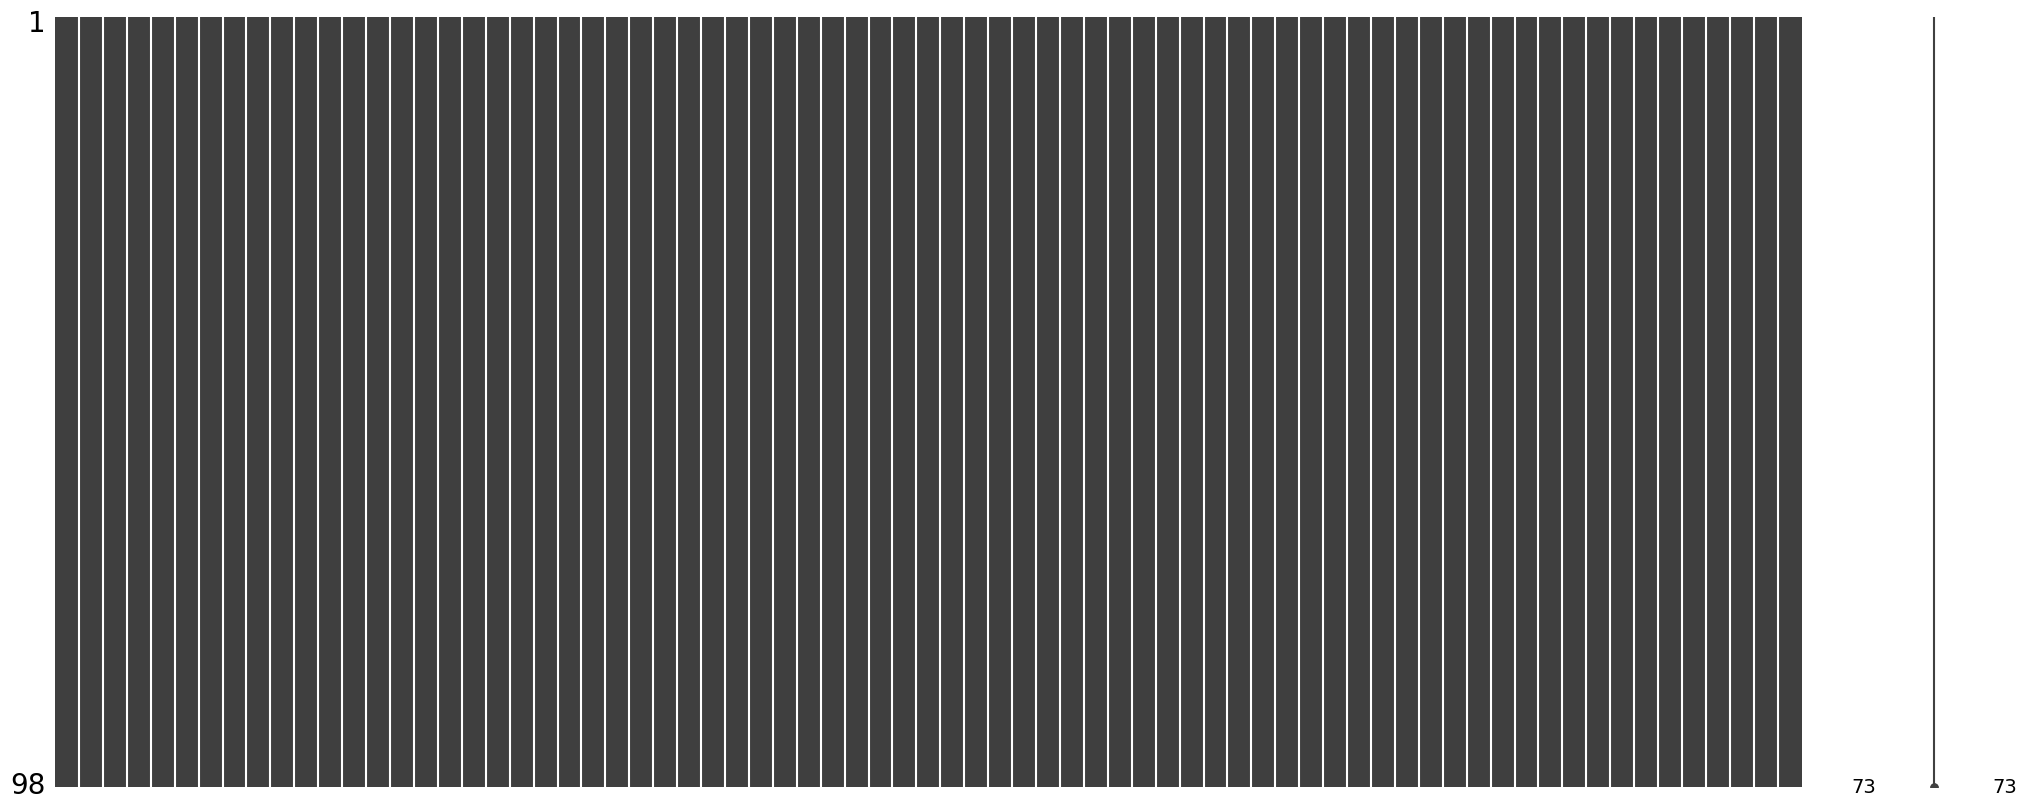

In [20]:
missingno.matrix(p2_df, label_rotation=90)

<Axes: >

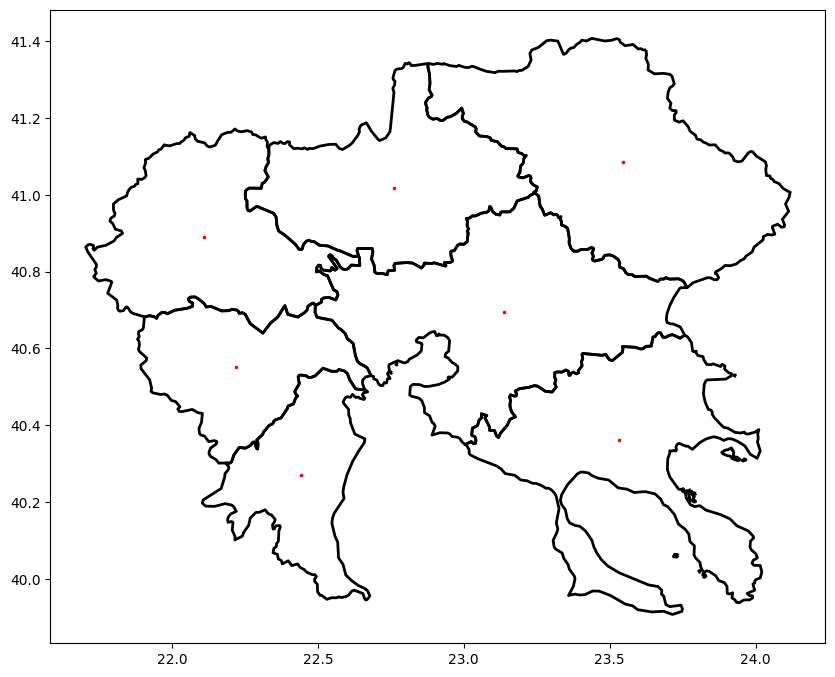

In [25]:
## Reading shapefiles from Greece

greece_nuts3_gdf = gpd.read_file(f"../../../../Europe NUTS - LAU Shapefiles/Greece/data/EL_Whole.shp",  encoding=enc)

greece_nuts3_gdf = greece_nuts3_gdf.to_crs(epsg=4326)

nuts3_gdf = greece_nuts3_gdf[greece_nuts3_gdf['NUTS2_ID'] == f'{NUTS2_ID}']

nuts3_points = gpd.GeoDataFrame(p1_df[['NUTS3_ID']], geometry=gpd.points_from_xy(p1_df.x, p1_df.y))

ax = nuts3_points.head(7).plot(markersize=2.5, figsize=(10, 10), color='red')
nuts3_gdf.plot(facecolor="none", edgecolor='black', ax=ax, lw=2)

In [26]:
p1_df.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_P1_2010_2023.csv", encoding = enc, index = False)
p2_df.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_P2_2010_2023.csv", encoding = enc, index = False)